# 02. Data Preparation for ML Tasks
## 📚 Learning Objectives

By completing this notebook, you will:
- Clean and prepare data for machine learning
- Handle missing values (detection, imputation, removal)
- Encode categorical variables (Label, One-Hot encoding)
- Prepare features for ML models
- Split data into train/test sets

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 03 "Data Preprocessing" and Course 05 — Unit 2 — the same imputation, encoding and splitting, now stated as the contract every model in this unit depends on.

**Used later in:** Course 05 — Unit 4, lessons 03-11, all of which start from the table this lesson produces.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Cleaning and preparing data for ML tasks (handling missing values, encoding categorical variables)

---

## The Story: Preparing Ingredients for a Recipe

Imagine you're cooking. **Before** you can cook, you prepare ingredients - clean vegetables, measure quantities, organize everything. **After** preparing, ingredients are ready to cook!

Same with ML: **Before** building models, we prepare data - clean, encode, split. **After** preparing, data is ready for models!

---

## Why Data Preparation for ML Matters

Data preparation is essential because:
- **Model Requirements**: ML models need specific data formats
- **Performance**: Well-prepared data improves model performance
- **Success**: Proper preparation is key to ML success
- **Standard Practice**: All ML workflows start with preparation

**Common Student Questions:**
- **Q: Why split data into train/test?**
  - Answer: Train on training set, evaluate on test set (unseen data)
  - Example: 80% train, 20% test
  - Benefit: Tests if model generalizes to new data
  
- **Q: When do I encode vs scale?**
  - Answer: Encode categorical (text → numbers), scale numerical (normalize range)
  - Example: Color (categorical) → encode, Age (numerical) → scale
  - Rule: Categories → encode, Numbers → scale

---

## Introduction

**Data preparation for ML** transforms raw data into ML-ready format. This involves cleaning, handling missing values, encoding categorical variables, and splitting data - all essential steps before building ML models.


## 🎯 The case: 294 papers, 17 fields, one preparation mistake

In 2023 Sayash Kapoor and Arvind Narayanan of Princeton published *"Leakage and the
reproducibility crisis in machine-learning-based science"* in *Patterns*. They surveyed
fields that had adopted machine learning and found **data leakage in 294 papers across 17
distinct fields** — medicine, political science, genomics, neuroimaging and more — in some
cases producing "wildly overoptimistic" published results. They catalogue **eight types of
leakage**, from textbook errors to genuinely open research problems.

Leakage is not a modelling bug. It is a **preparation** bug: information from the test set
reaching the model during training. Impute before splitting and the test set's mean is in
your training data. Scale before splitting and the test set's standard deviation is. Both
mistakes take one line and produce a validation score that is simply not real.

A specific, well-documented instance: Zech et al. (*PLOS Medicine*, 2018) trained
pneumonia-detection CNNs on 158,323 chest radiographs from three hospital systems, and
found the networks could **identify the hospital system itself** with high confidence.
Since disease prevalence differed by hospital, the models scored well internally and
worse externally — better internal than external performance in 3 of 5 comparisons.

**What goes wrong without this lesson — and the notebook does it right on purpose.** Below,
`StandardScaler` is fitted on the **training set only**, and the printout deliberately shows
the test set's mean coming out as −0.038 rather than exactly 0. That small imperfection is
the *evidence* that no leakage occurred. If your test set scales to a mean of exactly zero,
you have a bug.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `titanic.csv` — the 891-passenger manifest. We prepare it for a
  survival classifier. The missing values are the ones the historical record
  actually has: **177 missing ages**, **687 missing cabins**, **2 missing
  embarkation ports**. Nothing was deleted to create them.
- pandas, sklearn (SimpleImputer, LabelEncoder, StandardScaler, train_test_split)

**Outputs:** What you'll see when you run the cells

- The same table before and after imputation, encoding, splitting and scaling
- Counts and statistics printed at every step so you can audit what changed

---


In [1]:
# WHAT: Import pandas/NumPy plus sklearn's imputation, scaling, encoding, and splitting tools.
# WHY: These four preprocessing jobs turn raw tables into the numeric matrices ML models require.

# Imports
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# WHAT: Load the real Titanic manifest and inspect its genuine missing values and categorical columns.
# WHY: Preparation only makes sense against real defects - these gaps come from 1912 record-keeping,
#      not from a line of code that deleted values on purpose.

print("PART 1: Load real data with real missing values and real categories")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
raw = load("titanic")

# Keep the columns a survival model can actually use.
# 'Cabin' is dropped: 687 of 891 values are missing - imputing 77% of a column invents data.
df = raw[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked', 'Survived']].copy()
df = df.rename(columns={'Survived': 'target'})

print("Original data (real missing values and real categories):")
print(df.head(8).to_string())
print(f"\nShape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum().to_string())
print(f"\nCabin was dropped up front: {raw['Cabin'].isna().sum()} of {len(raw)} "
      f"({raw['Cabin'].isna().mean():.0%}) are missing - too many to impute honestly.")
print(f"Target balance: {df['target'].value_counts().to_dict()} "
      f"({df['target'].mean():.1%} survived)")

# ============================================================================

PART 1: Load real data with real missing values and real categories
----------------------------------------------------------------------
titanic: full file, 891 rows.
Original data (real missing values and real categories):
    Age     Fare  SibSp  Parch  Pclass     Sex Embarked  target
0  22.0   7.2500      1      0       3    male        S       0
1  38.0  71.2833      1      0       1  female        C       1
2  26.0   7.9250      0      0       3  female        S       1
3  35.0  53.1000      1      0       1  female        S       1
4  35.0   8.0500      0      0       3    male        S       0
5   NaN   8.4583      0      0       3    male        Q       0
6  54.0  51.8625      0      0       1    male        S       0
7   2.0  21.0750      3      1       3    male        S       0

Shape: (891, 8)

Missing values:
Age         177
Fare          0
SibSp         0
Parch         0
Pclass        0
Sex           0
Embarked      2
target        0

Cabin was dropped up front: 687 of 

In [3]:
# WHAT: Fill the 177 missing ages two ways - pandas fillna and sklearn's SimpleImputer.
# WHY: Both give the same numbers; the imputer is preferred because it can be fitted on the
#      training set alone and re-applied to test data, which fillna cannot do safely.

# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Handle Missing Values")
print("=" * 70)

# Method 1: Fill with mean
print("\n✅ Example 1: Fill Missing Values with Mean")
print("-" * 70)
df_filled_mean = df.copy()
age_mean = df_filled_mean['Age'].mean()
df_filled_mean['Age'] = df_filled_mean['Age'].fillna(age_mean)
print(f"Filled {df['Age'].isna().sum()} missing ages with the mean age {age_mean:.2f}")
print(f"Missing values remaining in numeric columns: "
      f"{df_filled_mean[['Age', 'Fare', 'SibSp', 'Parch']].isnull().sum().sum()}")
print("\n⚠️  Notice what mean-filling does to the distribution:")
print(f"   Age std before: {df['Age'].std():.2f}   after: {df_filled_mean['Age'].std():.2f}")
print("   Filling 20% of a column with one number shrinks its spread. That is a real cost,")
print("   and it is why median or model-based imputation is often preferred.")

# Method 2: Using SimpleImputer
print("\n✅ Example 2: Using SimpleImputer (Scikit-learn)")
print("-" * 70)
imputer = SimpleImputer(strategy='median')
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_imputed = df.copy()
df_imputed[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print(f"Median used for each numeric column: "
      f"{dict(zip(numeric_cols, imputer.statistics_.round(2)))}")
print("After imputation:")
print(df_imputed[numeric_cols].head().to_string())

# The 2 missing embarkation ports: fill with the most common port (mode).
mode_port = df_imputed['Embarked'].mode()[0]
n_missing_port = df_imputed['Embarked'].isna().sum()
df_imputed['Embarked'] = df_imputed['Embarked'].fillna(mode_port)
print(f"\nFilled {n_missing_port} missing embarkation ports with the mode '{mode_port}'")
print(f"Total missing values left: {df_imputed.isnull().sum().sum()}")

# ============================================================================


PART 2: Handle Missing Values

✅ Example 1: Fill Missing Values with Mean
----------------------------------------------------------------------
Filled 177 missing ages with the mean age 29.70
Missing values remaining in numeric columns: 0

⚠️  Notice what mean-filling does to the distribution:
   Age std before: 14.53   after: 13.00
   Filling 20% of a column with one number shrinks its spread. That is a real cost,
   and it is why median or model-based imputation is often preferred.

✅ Example 2: Using SimpleImputer (Scikit-learn)
----------------------------------------------------------------------
Median used for each numeric column: {'Age': np.float64(28.0), 'Fare': np.float64(14.45), 'SibSp': np.float64(0.0), 'Parch': np.float64(0.0)}
After imputation:
    Age     Fare  SibSp  Parch
0  22.0   7.2500    1.0    0.0
1  38.0  71.2833    1.0    0.0
2  26.0   7.9250    0.0    0.0
3  35.0  53.1000    1.0    0.0
4  35.0   8.0500    0.0    0.0

Filled 2 missing embarkation ports with th

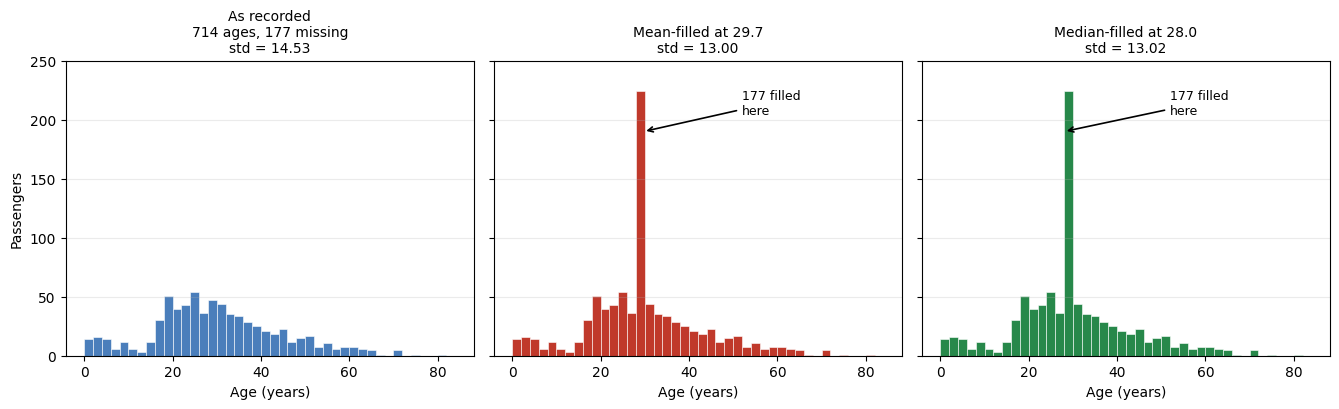

Tallest 2-year bin, as recorded :  54 passengers
Tallest 2-year bin, mean-filled : 224 passengers
Standard deviation  as recorded : 14.53
                    mean-filled : 13.00
                  median-filled : 13.02


In [4]:
# WHAT: Draw the age distribution three ways - as recorded, after mean-filling, after median-filling.
# WHY: The cell above PRINTED that filling shrinks the spread (std 14.53 -> 13.00). This shows
#      what that sentence looks like: one bin swallows 177 passengers who were never that age.
import matplotlib.pyplot as plt

age_raw = df['Age'].dropna()                      # 714 ages actually written on the manifest
age_mean_filled = df['Age'].fillna(df['Age'].mean())
age_median_filled = df['Age'].fillna(df['Age'].median())
bins = range(0, 85, 2)                            # 2-year bins, same for all three panels

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True, sharex=True)
panels = [
    (age_raw, f"As recorded\n{len(age_raw)} ages, {df['Age'].isna().sum()} missing", '#4a7ebb'),
    (age_mean_filled, f"Mean-filled at {df['Age'].mean():.1f}", '#c0392b'),
    (age_median_filled, f"Median-filled at {df['Age'].median():.1f}", '#27884a'),
]
for ax, (series, title, colour) in zip(axes, panels):
    ax.hist(series, bins=bins, color=colour, edgecolor='white', linewidth=0.4)
    ax.set_title(f"{title}\nstd = {series.std():.2f}", fontsize=10)
    ax.set_xlabel('Age (years)')
    ax.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('Passengers')

# Point at the single bin that absorbed all 177 imputed passengers.
for ax, fill_value in zip(axes[1:], [df['Age'].mean(), df['Age'].median()]):
    ax.annotate('177 filled\nhere', xy=(fill_value, 190), xytext=(52, 205),
                fontsize=9, ha='left',
                arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
axes[0].set_ylim(0, 250)
plt.tight_layout()
plt.show()

import numpy as np
h_raw, _ = np.histogram(age_raw, bins=bins)
h_mean, _ = np.histogram(age_mean_filled, bins=bins)
print(f"Tallest 2-year bin, as recorded : {h_raw.max():3d} passengers")
print(f"Tallest 2-year bin, mean-filled : {h_mean.max():3d} passengers")
print(f"Standard deviation  as recorded : {age_raw.std():.2f}")
print(f"                    mean-filled : {age_mean_filled.std():.2f}")
print(f"                  median-filled : {age_median_filled.std():.2f}")


**Read the figure.** Three histograms of the same column on identical 2-year bins. The
left panel is the age distribution as the manifest records it — 714 real ages, broadly spread
from infants to 80. The middle and right panels add the 177 missing passengers back in by
filling them with a single number, and in both a **spike appears out of nowhere**, at exactly
the fill value: 224 passengers in one 2-year bin, where the tallest bin of real ages holds 54. Every one of those 177 people is
now recorded as being the same age. The standard deviation printed above each panel falls from
**14.53** to **13.00**, and that single number is the whole cost: imputation did not recover
the missing ages, it invented a false peak and told the model that peak was real. Median-filling (28.0) lands in the
same 2-year bin as mean-filling (29.7) and shrinks the spread by just as much, to 13.02 — a
different fill value, the same invented peak. All three panels share one y-axis, so the
comparison is honest: nothing was rescaled to make the spike look bigger.

In [5]:
# WHAT: Turn the two text columns (Sex, Embarked) into numbers - label encoding and one-hot.
# WHY: Models do arithmetic; 'female' has no arithmetic. WHICH encoding you pick matters:
#      label encoding invents an order, one-hot does not.

# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Encode Categorical Variables")
print("=" * 70)

# Label Encoding
print("\n✅ Example 3: Label Encoding")
print("-" * 70)
label_encoder = LabelEncoder()
df_encoded = df_imputed.copy()
df_encoded['sex_encoded'] = label_encoder.fit_transform(df_encoded['Sex'])
print(df_encoded[['Sex', 'sex_encoded']].drop_duplicates().to_string(index=False))
print(f"\nEncoding mapping: "
      f"{dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print("💡 Safe here: 'Sex' has exactly two values, so 0/1 is just a flag, not a ranking.")

# One-Hot Encoding
print("\n✅ Example 4: One-Hot Encoding")
print("-" * 70)
df_onehot = pd.get_dummies(df_imputed, columns=['Embarked', 'Sex'],
                           prefix=['port', 'sex'], dtype=int)
port_cols = [c for c in df_onehot.columns if c.startswith('port_')]
print(f"One-hot encoded 'Embarked' into {len(port_cols)} columns: {port_cols}")
print(df_onehot[port_cols + ['sex_female', 'sex_male']].head().to_string())
print("\n💡 Why one-hot for 'Embarked'? Cherbourg=0, Queenstown=1, Southampton=2 would tell")
print("   the model Southampton is 'twice' Queenstown. It is not. One-hot removes that lie.")
print(f"   Port counts in the data: {df_imputed['Embarked'].value_counts().to_dict()}")

# ============================================================================


PART 3: Encode Categorical Variables

✅ Example 3: Label Encoding
----------------------------------------------------------------------
   Sex  sex_encoded
  male            1
female            0

Encoding mapping: {'female': np.int64(0), 'male': np.int64(1)}
💡 Safe here: 'Sex' has exactly two values, so 0/1 is just a flag, not a ranking.

✅ Example 4: One-Hot Encoding
----------------------------------------------------------------------
One-hot encoded 'Embarked' into 3 columns: ['port_C', 'port_Q', 'port_S']
   port_C  port_Q  port_S  sex_female  sex_male
0       0       0       1           0         1
1       1       0       0           1         0
2       0       0       1           1         0
3       0       0       1           1         0
4       0       0       1           0         1

💡 Why one-hot for 'Embarked'? Cherbourg=0, Queenstown=1, Southampton=2 would tell
   the model Southampton is 'twice' Queenstown. It is not. One-hot removes that lie.
   Port counts in the dat

In [6]:
# WHAT: Split into train and test sets, stratified on survival.
# WHY: The test set must stay unseen, and stratify keeps the 38% survival rate in BOTH halves -
#      without it a random split can hand you a test set with a different class balance.

# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Data Splitting")
print("=" * 70)

# Prepare features and target
feature_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass',
                'sex_female', 'sex_male'] + port_cols
X = df_onehot[feature_cols]
y = df_onehot['target']

# Train/Test Split
print("\n✅ Example 5: Train/Test Split")
print("-" * 70)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"\nOriginal data: {X.shape[0]} passengers")
print(f"Training set: {X_train.shape[0]} passengers ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} passengers ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"\nSurvival rate - full data {y.mean():.3f} | train {y_train.mean():.3f} "
      f"| test {y_test.mean():.3f}   <- stratify kept these equal")
print("\n💡 Training set: Used to train model")
print("💡 Test set: Used to evaluate model (unseen data)")

# ============================================================================


PART 4: Data Splitting

✅ Example 5: Train/Test Split
----------------------------------------------------------------------
Features used (10): ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'sex_female', 'sex_male', 'port_C', 'port_Q', 'port_S']

Original data: 891 passengers
Training set: 712 passengers (79.9%)
Test set: 179 passengers (20.1%)

Survival rate - full data 0.384 | train 0.383 | test 0.385   <- stratify kept these equal

💡 Training set: Used to train model
💡 Test set: Used to evaluate model (unseen data)


In [7]:
# WHAT: Standardize the numeric features - fit the scaler on TRAIN only, then transform both.
# WHY: Fitting the scaler on all the data leaks test statistics into training. This is the single
#      most common silent mistake in beginner ML pipelines.

# ============================================================================
print("\n" + "=" * 70)
print("PART 5: Feature Scaling")
print("=" * 70)

# Scale numerical features
print("\n✅ Example 6: Feature Scaling")
print("-" * 70)
scaler = StandardScaler()
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Before scaling - the ranges are wildly different:")
print(X_train[numeric_features].describe().loc[['mean', 'std', 'min', 'max']].round(2).to_string())
print("\nAfter scaling (training set):")
print(X_train_scaled[numeric_features].describe().loc[['mean', 'std', 'min', 'max']].round(2).to_string())
print("\nTest set after applying the SAME scaler (mean is near 0, not exactly 0 - correct!):")
print(X_test_scaled[numeric_features].describe().loc[['mean', 'std']].round(3).to_string())
print("\n💡 Fare ran from £0 to £512 while SibSp ran 0-8. Distance-based models would have")
print("   been driven almost entirely by Fare. Scaling puts them on comparable footing.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
✅ What you learned, preparing the real {len(raw)}-passenger Titanic manifest:
   1. Handle Missing Values: {raw['Age'].isna().sum()} real missing ages (median-imputed),
      {n_missing_port} missing ports (mode-filled), Cabin dropped ({raw['Cabin'].isna().mean():.0%} missing)
   2. Encode Categorical: label encoding for binary Sex, one-hot for the 3 ports
   3. Data Splitting: {len(X_train)} train / {len(X_test)} test, stratified on survival
   4. Feature Scaling: StandardScaler fitted on TRAIN only, then applied to test

🎯 Key Takeaways:
   - Missing Values: impute or drop - and say which, and how much
   - Encoding: one-hot when the categories have no order
   - Splitting: stratify so both halves share the class balance
   - Scaling: fit on train, transform test - never the other way round

📚 Next Steps:
   - Example 3: Implementing ML Models (this prepared data feeds straight in)
""")
print("✅ Data preparation - complete!")


PART 5: Feature Scaling

✅ Example 6: Feature Scaling
----------------------------------------------------------------------
Before scaling - the ranges are wildly different:
        Age    Fare  SibSp  Parch
mean  29.46   31.82   0.49   0.39
std   13.03   48.06   1.06   0.84
min    0.42    0.00   0.00   0.00
max   80.00  512.33   8.00   6.00

After scaling (training set):
       Age   Fare  SibSp  Parch
mean  0.00  -0.00  -0.00  -0.00
std   1.00   1.00   1.00   1.00
min  -2.23  -0.66  -0.47  -0.47
max   3.88  10.01   7.08   6.70

Test set after applying the SAME scaler (mean is near 0, not exactly 0 - correct!):
        Age   Fare  SibSp  Parch
mean -0.038  0.040  0.141 -0.053
std   0.997  1.163  1.181  0.793

💡 Fare ran from £0 to £512 while SibSp ran 0-8. Distance-based models would have
   been driven almost entirely by Fare. Scaling puts them on comparable footing.

Summary

✅ What you learned, preparing the real 891-passenger Titanic manifest:
   1. Handle Missing Values: 177 re

## ⚠️ Where this breaks

- **Order of operations is the whole game.** Split **first**, then fit imputers, scalers and
  encoders on the training half only. Anything fitted before the split leaks. The safe
  version is a `Pipeline` — it makes the correct order the only order — and Unit 5 lesson
  05 builds one.
- **A random split assumes the rows are exchangeable.** They very often are not. Time series
  need a chronological split (train on the past, test on the future); grouped data — several
  rows per patient, per household, per ticket — needs `GroupKFold`, or the same person
  appears on both sides and your score is fiction. This manifest has 210 passengers sharing
  ticket numbers.
- **One 80/20 split is a single noisy estimate.** With 179 test passengers, one extra
  correct prediction moves accuracy by 0.6 percentage points. Cross-validation gives you a
  spread instead of a point; report it.
- **Encoders and imputers break on unseen values at inference time.** A new port, a new
  category, an all-NaN column — each is a production error your notebook never sees. Set
  `handle_unknown='ignore'` and test the failure path.
- **The assumption that must hold: the test set resembles what the model will actually
  meet.** Every number in this notebook is a claim about 1912 passenger records. Zech's
  CNNs met that limit at hospital boundaries; the concept-drift lesson in Unit 5 meets it
  at a calendar boundary.
- **Cheaper alternative:** several strong tabular models need almost none of this. XGBoost
  and LightGBM handle missing values natively and split on categories directly — no
  imputation, no one-hot, no scaling. Preprocess because *your chosen model* requires it,
  not out of ritual.


## 💬 Discuss

The pipeline made four decisions on real data: **Cabin dropped (687 of 891 missing)**,
**177 ages median-imputed (28.0)**, **2 ports mode-filled with 'S'**, and a **stratified
80/20 split** that held survival at 0.383 in train and 0.385 in test.

1. Dropping `Cabin` removed a column that Unit 2 lesson 02 showed is missing 18.5% of the
   time in first class and 97.6% in third — i.e. missingness itself predicts class, which
   predicts survival. Was dropping it the right call? Argue for keeping a
   `cabin_recorded` flag instead, then argue against.
2. `stratify` kept the survival rate equal in both halves, which makes the test score more
   stable. It also means your test set is *not* a plain random sample of future passengers.
   When is that a feature and when is it a distortion?
3. Mean-imputing `Age` shrank its standard deviation from 14.53 to 13.00 — a fifth of the
   column is now one number. Design the check you would run *after* training to find out
   whether the model is treating imputed passengers differently from real ones. What would
   you do if it were?


## 📚 References

1. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. <https://arxiv.org/abs/1201.0490>
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>
3. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
4. Liang, H., Ma, X., Liu, Z., et al. (2025). *DataFlow: An LLM-Driven Framework for Unified Data Preparation and Workflow Automation in the Era of Data-Centric AI*. arXiv:2512.16676. <https://arxiv.org/abs/2512.16676>
5. Bayram, F., Ahmed, B. S., & Hallin, E. (2025). *End-to-End Data Quality-Driven Framework for Machine Learning in Production Environment*. arXiv:2512.19723. <https://arxiv.org/abs/2512.19723>
